# Phase Diagram Analysis

## Objective

The phase diagram is constructed to identify the regions of stable and unstable operation of the two-bus transportation system in the parameter space spanned by the loading parameter, $\Gamma$, and the speedup parameter, $S$.

The system dynamics are governed by the nonlinear map

$$
T_i(m+1)
=

T_i(m)
+
\Gamma
\left(
T_i(m)-T_i'(m')
\right)
+
\frac{1}
{1+S_i\left(T_i(m)-T_i'(m')\right)},
$$

where $\Gamma$ represents the passenger loading effect, $S_i$ denotes the speedup capability of bus $i$, and

$$
\Delta T_i(m)=T_i(m)-T_i'(m')
$$

is the temporal headway between consecutive bus departures.

The two parameters have opposite effects on the system dynamics. Increasing $\Gamma$ amplifies passenger accumulation and tends to destabilize the schedule, whereas increasing $S$ enables delayed buses to recover by reducing their travel times and therefore promotes stability. Consequently, the phase diagram can be interpreted as a stability map indicating which combinations of $(\Gamma,S)$ lead to regular operation and which generate periodic or chaotic behavior.

---

## Order Parameter

To characterize the dynamical state of the system, the root-mean-square (RMS) fluctuation of the bus headway is used as an order parameter.

For bus 2, the headway sequence is defined by

$$
H_2(k)
=

\left|
T_2(k+1)-T_2(k)
\right|,
$$

with mean value

$$
\bar H_2
=

\frac{1}{N}
\sum_{k=1}^{N}
H_2(k).
$$

The RMS fluctuation is then computed as

$$
H_{2,\mathrm{rms}}
=

\sqrt{
\frac{1}{N}
\sum_{k=1}^{N}
\left(
H_2(k)-\bar H_2
\right)^2
}.
$$

For regular motion, all headways are identical and

$$
H_{2,\mathrm{rms}} \approx 0.
$$

When the system becomes periodic, the headway oscillates between several discrete values and the RMS becomes positive. In the chaotic regime, the headway fluctuates irregularly and generally produces larger RMS values. Therefore, $H_{2,\mathrm{rms}}$ serves as an effective indicator of the transition from regular to preodic or chaos motion.

---

## Transition Point Detection

For each fixed value of the speedup parameter $S$, the loading parameter $\Gamma$ is gradually increased from $0$ to $2$. For every value of $\Gamma$, the system is simulated for a sufficiently long time, the transient dynamics are discarded, and the headway sequence of bus 2 is extracted to compute

$$
H_{2,\mathrm{rms}}(\Gamma).
$$

To detect the onset of instability, finite differences of the RMS curve are evaluated. The first derivative is approximated by

$$
g_1(i)
=

\frac{
H_{2,\mathrm{rms}}(\Gamma_{i+1})
-

H_{2,\mathrm{rms}}(\Gamma_i)
}{
\Gamma_{i+1}-\Gamma_i
},
$$

and the second derivative is approximated by

$$
g_2(i)
=

\frac{
g_1(i+1)-g_1(i)
}{
\Gamma_{i+1}-\Gamma_i
}.
$$

Rather than locating the global maximum of the second derivative, the transition point is identified as the first value of $\Gamma$ for which the curvature exhibits a sudden increase. Numerically, the criterion is

$$
g_2(k)-g_2(k-2)>\delta,
$$

where the threshold is chosen as

$$
\delta = 130.
$$

The corresponding loading parameter is then defined as

$$
\Gamma_c = \Gamma_k.
$$

This criterion detects the earliest rapid growth of headway fluctuations and therefore provides an estimate of the boundary between regular operation and oscillatory or chaotic dynamics.

---

## Construction of the Phase Diagram

Repeating the above procedure for all investigated values of $S$ yields a set of critical points,

$$
\left(\Gamma_c(S),S\right).
$$

Plotting these points produces the transition line separating two dynamical regimes:

* **Above the transition line:** regular and stable bus operation;
* **Below the transition line:** periodic or chaotic headway fluctuations.

The phase diagram therefore quantifies how much speedup capability is required to suppress instability and maintain regular shuttle-bus operation under increasing passenger demand.


**Initial Condition** 

In [23]:
T1_initial = 0.1
T2_initial = 0.1


**Simulation**

In [ ]:
import sys 
sys.path.append('/home/thangdoi/MathematicalModellingProject/src/')
from simulator.simulation import simulate_bus_system

In [37]:

import numpy as np    
from tqdm import tqdm 

x_vals = []  
y_vals = []  

for S in np.linspace(0, 2, 50):
    x = []
    grad_1 = []
    grad_2 = []
    t2_rms = []
    transition_point = 0
    for gamma in tqdm(np.linspace(0, 2, 1000)):
        arrival_time = simulate_bus_system(T1_initial=T1_initial, T2_initial=T2_initial, gamma=gamma, S1=S, S2=S, num_trips=2000)
        arrival_time_2 = np.array([t[0] for t in arrival_time if t[1] == 2 and 900 <= t[2] <= 1000])
        T2 = np.abs(arrival_time_2[1:] - arrival_time_2[:-1]) if len(arrival_time_2) > 1 else np.array([])
        
        T2_mean = np.mean(T2)
        T2_rms = np.sqrt(np.mean(np.square(T2 - T2_mean)))
        t2_rms.append(T2_rms)
        x.append(gamma)
    
    print("Calculate RMS successfully\nFinding transition point")
    # Process
    x = np.array(x)
    t2_rms = np.array(t2_rms)
    for i in range(len(t2_rms) - 1):
        grad = (t2_rms[i+1] - t2_rms[i])/(x[i+1] - x[i])
        grad_1.append(grad)
    for j in range(len(grad_1) - 1):
        grad = (grad_1[j+1] - grad_1[j])/(x[j+1] - x[j])
        grad_2.append(grad)
    
    if len(grad_2) == 0:
        print(f"S = {S:.2f}: Insufficient data")
        continue

    for k in tqdm(range(2, len(grad_2) - 2)):
        
        # print(f"At index {k} -> grad_2 = {grad_2[k]} and gamma = {x[k]}")
        if grad_2[k] - grad_2[k-2] > 130:
            transition_point = x[k]
            print(f"S = {S}, transition at gamma = {transition_point}\n")
            x_vals.append(transition_point)
            y_vals.append(S)
            break

100%|██████████| 1000/1000 [00:04<00:00, 227.93it/s]


Calculate RMS successfully
Finding transition point


  9%|▊         | 85/994 [00:00<00:00, 1485482.67it/s]


S = 0.0, transition at gamma = 0.17417417417417416



100%|██████████| 1000/1000 [00:04<00:00, 231.80it/s]


...

S = 1.9591836734693877, transition at gamma = 0.6606606606606606



100%|██████████| 1000/1000 [00:04<00:00, 232.77it/s]


Calculate RMS successfully
Finding transition point


 33%|███▎      | 330/994 [00:00<00:00, 3451671.62it/s]

S = 2.0, transition at gamma = 0.6646646646646647



**Phase Diagram**

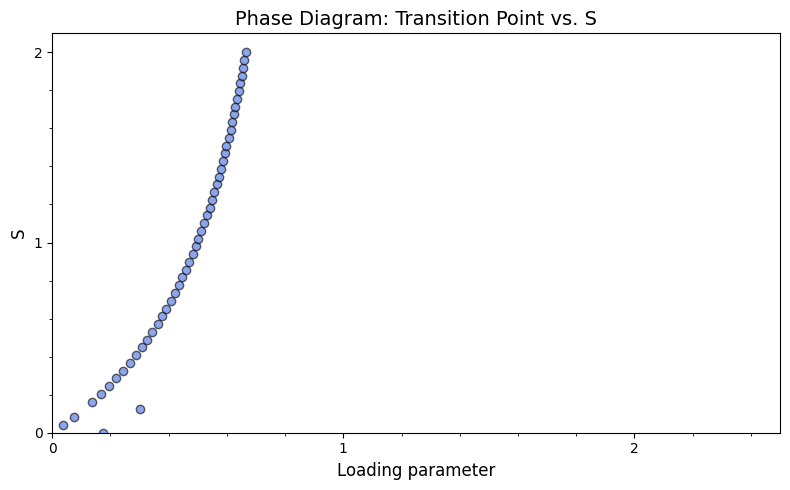

In [38]:
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
# Plot
plt.figure(figsize=(8, 5))
plt.scatter(x_vals, y_vals, alpha=0.6, color='royalblue', edgecolors='black')
plt.xlabel("Loading parameter", fontsize=12)
plt.ylabel("S", fontsize=12)
plt.title("Phase Diagram: Transition Point vs. S", fontsize=14)
plt.xlim(0, 2.5)
plt.ylim(0, 2.1)

ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))
plt.xticks([0, 1, 2])
plt.yticks([0, 1, 2])
plt.minorticks_on()
plt.tight_layout()
plt.show()